Kütüphanelerin Kurulumu

In [1]:
import warnings
warnings.filterwarnings("ignore")
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

Transfer Functions (Continuous to Binary)

Algoritmanın ürettiği sürekli (ondalıklı) değerleri özellik seçimi için 
ikili uzaya (0 ve 1) eşleyen S-şekilli (Sigmoid) ve V-şekilli transfer fonksiyonları burada tanımlanmıştır.

In [2]:
def sigmoid_transfer(x: np.ndarray) -> np.ndarray:
    x = np.clip(x, -10, 10)
    return 1 / (1 + np.exp(-x))

def v_shaped_transfer(x: np.ndarray) -> np.ndarray:
    x = np.clip(x, -10, 10)
    return np.abs(np.tanh(x))

Piecewise Chaos Mapping

Orijinal makaledeki popülasyon çeşitliliğini artırma stratejisidir. 
Ceylanların rastgele değil, arama uzayını dengeli tarayacak şekilde kaos haritasıyla dağılmasını sağlar.

In [3]:
def piecewise_chaos_initialization(pop_size: int, dim: int) -> np.ndarray:
    P = 0.4
    X_chaos = np.zeros((pop_size, dim))
    val = np.random.rand(dim)
    for i in range(pop_size):
        for j in range(dim):
            if 0 <= val[j] < P:
                val[j] = val[j] / P
            elif P <= val[j] < 0.5:
                val[j] = (val[j] - P) / (0.5 - P)
            elif 0.5 <= val[j] < 1 - P:
                val[j] = (1 - P - val[j]) / (0.5 - P)
            else:
                val[j] = (1 - val[j]) / P
        X_chaos[i, :] = val * 10 - 5
    return X_chaos

Fitness Function with Random Forest

Random Forest entegre edilmiştir. 
Amaç fonksiyonu, hatayı (RMSE) minimize ederken en az sayıda özellik seçilmesini cezalandırma mekanizmasıyla yönetir.


In [4]:
def evaluate_fitness(selected_indices, X_train, X_test, y_train, y_test, alpha, beta, n_estimators=50):
    if np.sum(selected_indices) == 0:
        return float('inf'), float('inf'), float('inf'), float('inf')
        
    X_train_sel = X_train.iloc[:, selected_indices == 1]
    X_test_sel = X_test.iloc[:, selected_indices == 1]
    
    # Gelişmiş Wrapper Model: Random Forest
    model = RandomForestRegressor(n_estimators=n_estimators, random_state=42, n_jobs=-1)
    model.fit(X_train_sel, y_train)
    predictions = model.predict(X_test_sel)
    
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    
    total_features = X_train.shape[1]
    selected_count = np.sum(selected_indices)
    
    fitness = (alpha * rmse) + (beta * (selected_count / total_features))
    return fitness, rmse, mae, r2

Core Binary MPSOGOA Implementation

PSO'nun bireysel hafıza matrisi ile GOA'nın ceylan otlama/kaçış dinamiklerinin hibritlendiği ana arama motorudur. 
Global perturbation adımı ile yerel minimum tuzaklarından kaçış sağlanır.

In [5]:
def run_bMPSOGOA(X_train, X_test, y_train, y_test, transfer_type='sigmoid', 
                 pop_size=10, max_iter=15, alpha=0.99, beta=0.01, n_estimators=50):
    total_features = X_train.shape[1]
    X = piecewise_chaos_initialization(pop_size, total_features)
    V = np.zeros((pop_size, total_features))
    
    pbest_X = np.copy(X)
    pbest_fitness = np.full(pop_size, float('inf'))
    
    gbest_X = np.zeros(total_features)
    gbest_fitness = float('inf')
    gbest_metrics = {'rmse': float('inf'), 'mae': float('inf'), 'r2': -float('inf'), 'count': 0}
    
    convergence_history = []
    w_max, w_min = 0.9, 0.4
    c1, c2 = 1.5, 1.5
    
    for t in range(max_iter):
        w = w_max - t * ((w_max - w_min) / max_iter)
        
        for i in range(pop_size):
            # Seçilen transfer fonksiyonuna göre binarizasyon
            if transfer_type == 'sigmoid':
                prob = sigmoid_transfer(X[i])
                X_bin = (prob > 0.5).astype(int)
            else:
                prob = v_shaped_transfer(X[i])
                X_bin = (prob > np.random.rand(total_features)).astype(int)
                
            if np.sum(X_bin) == 0:
                X_bin[np.random.randint(0, total_features)] = 1
                
            fit, rmse, mae, r2 = evaluate_fitness(X_bin, X_train, X_test, y_train, y_test, alpha, beta, n_estimators)
            
            if fit < pbest_fitness[i]:
                pbest_fitness[i] = fit
                pbest_X[i] = np.copy(X[i])
                
            if fit < gbest_fitness:
                gbest_fitness = fit
                gbest_X = np.copy(X[i])
                gbest_metrics = {'rmse': rmse, 'mae': mae, 'r2': r2, 'count': np.sum(X_bin), 'binary': X_bin}
                
        convergence_history.append(gbest_metrics['rmse'])
        
        # Matematiksel Hız ve Pozisyon Güncellemeleri
        for i in range(pop_size):
            r1, r2, r3 = np.random.rand(), np.random.rand(), np.random.rand()
            V[i] = w * V[i] + c1 * r1 * (pbest_X[i] - X[i]) + c2 * r2 * (gbest_X - X[i])
            
            if r3 < 0.5:
                X[i] = X[i] + V[i] * np.random.normal(0, 1, total_features)
            else:
                levy_step = np.random.standard_cauchy(total_features)
                X[i] = X[i] + V[i] + (gbest_X - X[i]) * levy_step
                
            if np.random.rand() < 0.1: # Global Pertürbasyon Stratejisi
                X[i] = X[i] + np.random.uniform(-1, 1, total_features)
                
    return gbest_metrics, convergence_history

Data Loading and Split

In [6]:
file_path = 'energydata_complete.csv'
df = pd.read_csv(file_path)
X = df.drop(columns=['date', 'Appliances'])
y = df['Appliances']
feature_names = X.columns
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Data successfully split. Features size: {X.shape[1]}, Instances: {X.shape[0]}")

Data successfully split. Features size: 27, Instances: 19735


Execution and Convergence Curve Visualization

Executing Production bMPSOGOA...

             🎯 FINAL RESULTS 🎯             
• Optimal Selected Features Count : 14 / 27
• Root Mean Squared Error (RMSE)  : 61.6506
• Mean Absolute Error (MAE)       : 29.5266
• Coefficient of Determination (R²): 0.6202

• Selected Feature Names:
T1, RH_2, T4, T6, RH_6, RH_7, T8, RH_8, T9, T_out, Press_mm_hg, Windspeed, Visibility, Tdewpoint


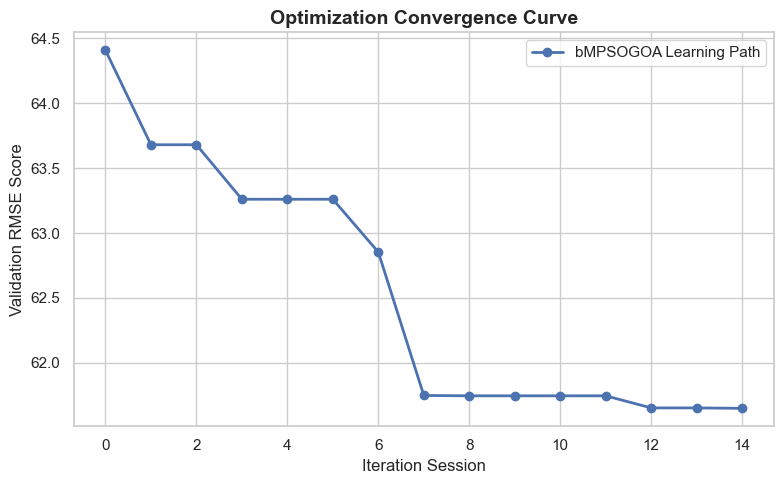

In [ ]:
print("Executing Production bMPSOGOA...")
metrics, history = run_bMPSOGOA(X_train, X_test, y_train, y_test, transfer_type='sigmoid', max_iter=15)

print("\n" + "="*50)
print("              FINAL RESULTS              ")
print("="*50)
print(f"• Optimal Selected Features Count : {metrics['count']} / {X.shape[1]}")
print(f"• Root Mean Squared Error (RMSE)  : {metrics['rmse']:.4f}")
print(f"• Mean Absolute Error (MAE)       : {metrics['mae']:.4f}")
print(f"• Coefficient of Determination (R²): {metrics['r2']:.4f}")

selected_features = feature_names[metrics['binary'] == 1].tolist()
print(f"\n• Selected Feature Names:\n{', '.join(selected_features)}")
print("="*50)

# Yakınsama Eğrisinin Çizilmesi
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")
plt.plot(history, marker='o', color='b', linewidth=2, label='bMPSOGOA Learning Path')
plt.title('Optimization Convergence Curve', fontsize=14, fontweight='bold')
plt.xlabel('Iteration Session', fontsize=12)
plt.ylabel('Validation RMSE Score', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()